In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.model.single_pass import SinglePassConfidence
from model.spatial_transformer_classifier import SpatialTransformerClassifier
from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_mnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}
should_gmm = True


architecture = default_architecutre_mapping[dataset]
budget = None

In [2]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [3]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']



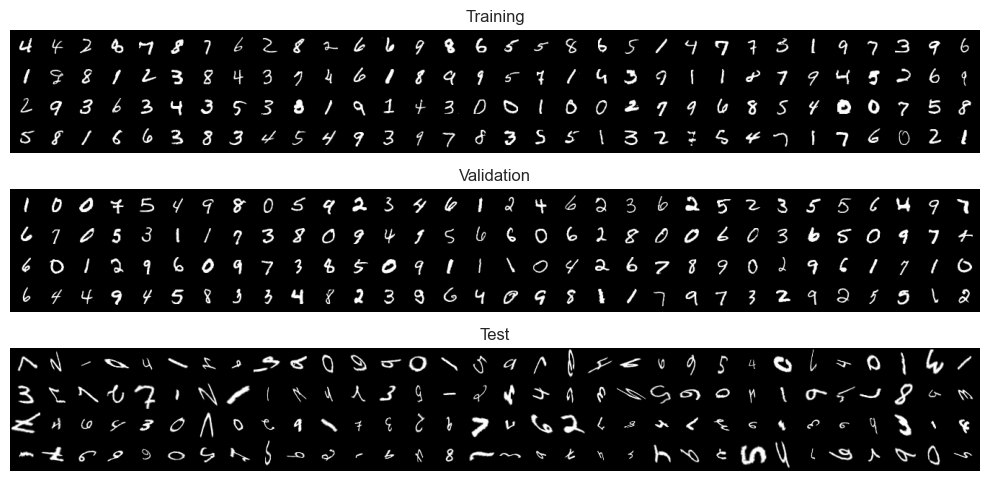

In [4]:
x = next(iter(test_loader_transformed))[0]

batch_size = next(iter(train_loader))[0].shape[0]

from utils.eval.vis import vis_dataset

vis_dataset(train_loader, val_loader, test_loader_transformed)
from experiment_thesis.main import train_and_get_model, train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,
                                "comparison_unsupervised")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, transform_name, f"{safe}.json")

In [5]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [6]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [7]:
#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


{'accuracy': 0.9955999851226807, 'f2_macro': 0.9955340027809143, 'f2_micro': 0.9955999851226807, 'f2_weighted': 0.9955984354019165}


In [8]:
from utils.transforms.scale import Scale, DirectedScale, ScaleAllSame

is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

from utils.replacer import replace_rotation_transforms_2vec,replace_scaling_transforms,replace_rotation_transforms


from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [9]:
print(transform_seq.transformations)

[<utils.transforms.rotation.Rotation2D object at 0x0000022793CE3BE0>, <utils.transforms.shear.DirectedShear object at 0x0000022793D1FB20>, <utils.transforms.shear.DirectedShear object at 0x0000022793D1FB80>, <utils.transforms.scale.DirectedScale object at 0x0000022793D1EEF0>, <utils.transforms.scale.DirectedScale object at 0x0000022793D1EF50>]


In [10]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)



In [11]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)


In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [13]:
from experiment_thesis.ood import base_prepare

base_prepare.OOD_PARAM_SAMPLERS.keys()

dict_keys(['energy', 'energy_ts', 'max_logit', 'entropy', 'max_softmax', 'differentiable_max_softmax', 'adjusted_entropy', 'cross_entropy', 'ash', 'gradnorm', 'laplace_prob', 'laplace_energy', 'laplace_variance', 'laplace_mutual_information', 'laplace_entropy_plus_mi', 'laplace_entropy', 'laplace_weighted', 'laplace_mi', 'laplace_best_criterion', 'laplace_entropy_gridsearch', 'mc_dropout_prob', 'mc_dropout_variance', 'mc_dropout_mi', 'mc_dropout_energy', 'mc_dropout_last_layer_prob', 'mc_dropout_last_layer_variance', 'mc_dropout_last_layer_mi', 'mc_dropout_last_layer_energy', 'mc_batchnorm_prob', 'mc_batchnorm_variance', 'mc_batchnorm_mi', 'mc_batchnorm_energy', 'mc_dropout_best_criterion', 'mc_batchnorm_best_criterion', 'mc_dropout_last_layer_best_criterion', 'react', 'react_all', 'dice', 'gaussian', 'gmm', 'gram', 'kde', 'kl_matching', 'faiss_knn', 'faiss_per_class_knn', 'knn', 'per_class_knn', 'knn_trap', 'per_class_knn_trap', 'knn_mixed', 'per_class_knn_mixed', 'knn_mahalanobis', '

In [14]:
detectors = ["knn","per_class_knn", "knn_mixed","per_class_knn_mixed","knn_mixed_faiss","knn_itf","vim","react","dice","ash","she","laplace_mi","laplace_energy","laplace_weighted","trust_score","openmax","mahalanobis","rmd","class_prototype","react_all","energy","per_class_prototype","single_mahalanobis","single_rmd","single_mahalanobis_individual","single_rmd_individual","mahalanobis_individual","rmd_individual","prototype_multi", "laplace_entropy","adjusted_entropy","nn_guided","nn_guided_one"]
#dont do kde to expensive, and not better.
#global protoype makes no sense over class based protoype
# lof fit is to slow, gmm is even slower or fails due to size
# gram runs out of main memory,

detectors_parameterless = ["energy_ts","entropy","kl_matching","laplace_entropy_gridsearch"]
detectors = detectors + detectors_parameterless
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet
if not isinstance(model,FlexibleResNet):
    #remove ash and react_all as they only work with resnets
    detectors.remove("ash")
    detectors.remove("react_all")
    if "react" not in detectors:
        detectors.append("react")
    detectors.append("ash_last")



In [15]:
# python
import os
import json
import math
import torch
from typing import Tuple, Optional, Any, Dict

from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

# Example call (update unpacking to 6 values)
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [16]:
#here we do the following calculate the accuracy on the test set, then calculate on the transformed test set. We also store the confidence valeus
#then we do the optimiztation to find which ones we can transform to get better accuracy.
#we then draw the curve over the threshold when we switch from doing no optimization to doing optimization, this should drop the accuracy on the test set but increase on the transformed test set.



In [17]:
transform_seq_spatial = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
).to(device)
from utils.transforms.scale import Scale, DirectedScale, ScaleAllSame

is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]




from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq2 = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    from utils.transforms.rotation import RotationSkew3D
    transform_seq2 = replace_rotation_transforms_2vec(transform_seq2)

else:
    transform_seq2 = replace_rotation_transforms(transform_seq)
if dataset=="coil100":
    transform_seq2 = replace_scaling_transforms(transform_seq2, replace_scale=False)
transform_seq_spatial = transform_seq2




In [18]:
train_loader_augmented = dataset_dict.get('train_loader_augmented', None)

In [19]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

In [20]:
layer,layer_io = get_network_layer(dataset_info, architecture, 1, num_classes=None, num_rotations=8)

In [21]:
from embedding_cache import LayerEmbeddingCache
cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)


In [22]:
from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule
from confidence.direct.targeted import CrossEntropyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
from confidence.unsupervised.classic.prototype import ClassPrototypeConfidence
from confidence.control.split import TrueLabelSplitConfidence
from utils.transformation_problem import TransformationProblem

nn_pytorch_pretrained = ClassPrototypeConfidence(metric="cosine")
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = TrueLabelSplitConfidence(nn_pytorch_pretrained, CrossEntropyConfidence(), mult=False,a=10,b=1)


conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_guided = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq_spatial,consolidate_method="consolidate_simple")
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [23]:
from utils.transformation_problem import TransformationProblem


In [24]:
transform_seq_spatial.transformations

In [25]:
from dataset.geometric_wrapper import TransformParamDataset
import search.shgo
import importlib
import tqdm


train_loader_transformed_no_shuffle = dataset_dict['train_loader_transformed_no_shuffle']


import search.shgo
import importlib
import tqdm
import os
import pickle


importlib.reload(search.shgo)

# Define cache path
regression_cache_path = os.path.join(
    embedding_cache_path,
    f"regression_params_{dataset}_{architecture}_{transform_name}_test_set.pkl"
)

if os.path.exists(regression_cache_path):
    print(f"Loading cached regression parameters from {regression_cache_path}")
    with open(regression_cache_path, 'rb') as f:
        cache_data = pickle.load(f)
        regression_target = cache_data['regression_target']
        test_acc_sim = cache_data['test_acc_sim']
else:
    print("Computing regression parameters (this may take a while)...")
    di = search.shgo.SHGO(selection_method="topk", initial_samples=108+120, local_runs=2, local_max_steps=3, local_opt_kwargs={"lr":0.1})
    if dataset == "tu_berlin":
        di = search.shgo.SHGO(selection_method="topk", initial_samples=240, local_runs=1, local_max_steps=0, local_opt_kwargs={"lr":0.1})

    model.eval().cuda()

    regression_target = []
    test_acc_sim = 0.0
    counter = 0
    problem_guided.max_batch_size =dataset_info.batch_size_search
    bar = tqdm.tqdm(test_loader_transformed)
    first=True
    print()
    try:
        for data, target in bar:
            data, target = data.cuda(), target.cuda()
            res = di.optimize(problem_guided, data.cuda(), y=target.cuda())
            zw = transform_seq_spatial.normalize(res[0])
            regression_target.append(zw.detach().cpu())

            # Apply the transformation and get predictions
            x_transformed2 = problem_guided.transform(data.cuda(), zw)
            logits = model(x_transformed2)
            output = logits.argmax(dim=-1)
            test_acc_sim += output.eq(target).sum().item()
            counter += output.shape[0]
            #update bar with intermediate accuracy
            if first and is_image_data:
                first=False
                #plot
                import matplotlib.pyplot as plt
                grid_orig = torchvision.utils.make_grid(data.cpu(), nrow=8, normalize=True, scale_each=True)
                grid_transformed = torchvision.utils.make_grid(x_transformed2.cpu(), nrow=8, normalize=True, scale_each=True)
                plt.figure(figsize=(12, 6))
                plt.subplot(1, 2, 1)
                plt.title("Original Images")
                plt.imshow(grid_orig.permute(1, 2, 0))
                plt.axis('off')
                plt.subplot(1, 2, 2)
                plt.imshow(grid_transformed.permute(1, 2, 0))
                plt.title("Transformed Images")
                plt.show()
                print()
            #flush bar
            bar.refresh()
            bar.set_description(f"Intermediate transformed accuracy: {test_acc_sim / counter:.4f}")

    finally:
        bar.close()

    test_acc_sim /= counter
    regression_target = torch.cat(regression_target, dim=0)

    # Save to cache
    os.makedirs(os.path.dirname(regression_cache_path), exist_ok=True)
    with open(regression_cache_path, 'wb') as f:
        pickle.dump({
            'regression_target': regression_target,
            'test_acc_sim': test_acc_sim
        }, f)
    print(f"Cached regression parameters to {regression_cache_path}")



regression_dataset = TransformParamDataset(test_loader_transformed.dataset, regression_target)
regression_dataloader = torch.utils.data.DataLoader(
    regression_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    persistent_workers=True
)

print(f'With class knowledge we can define a canonical representation of the data: {test_acc_sim}.')



Loading cached regression parameters from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\embedding_cache\regression_params_bigger_mnist_resnet_small_biggermnist_default_test_set.pkl
With class knowledge we can define a canonical representation of the data: 1.0.


In [26]:
test_loader_transformed.dataset[0]


(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 tensor(7))

In [27]:
regression_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 tensor([ 0.1619, -0.9868, -0.1998, -0.0450,  0.5812,  0.4508]),
 tensor(7))

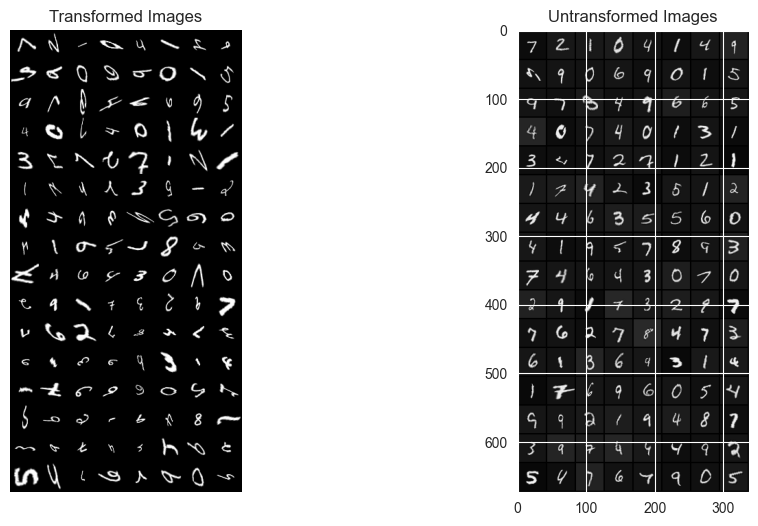

In [28]:
#test the regression true dataset
if is_image_data:
    x,p,y =next(iter(regression_dataloader))
    T = transform_seq_spatial(p)
    #T = torch.linalg.inv(T)
    x_untransformed = transform_seq_spatial.application_method(x, T)

    plt.figure(figsize=(12, 6))
    grid_orig = torchvision.utils.make_grid(x.cpu(), nrow=8, normalize=True, scale_each=True)
    grid_untransformed = torchvision.utils.make_grid(x_untransformed.cpu(), nrow=8, normalize=True, scale_each=True)
    plt.subplot(1, 2, 1)
    plt.title("Transformed Images")
    plt.imshow(grid_orig.permute(1, 2, 0))
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(grid_untransformed.permute(1, 2, 0))
    plt.title("Untransformed Images")
    plt.show()






In [29]:
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})

if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

In [30]:
# python
import os
import json
import math
import torch
from typing import Tuple, Optional, Any, Dict

from experiment_thesis.ood.base_prepare import create_ood_problem, get_default_ood_params

def find_best_detector_and_instantiate(
    base_results_dir: str,
    detectors: list,
    model,
    train_cache,
    transform_seq_arg,
    dataset_info,
    architecture: str,
    device,
    val_id_loader,
    val_ood_loader,
    prefer_second: Optional[str] = None,
) -> Tuple[
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
    Optional[str],
    Optional[Any],
    Optional[Dict[str, float]],
]:
    """
    Find best detector by recorded `accuracy_mean` (preferring mean) and instantiate its OOD problem.
    Returns:
      (best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict)
    where score dict is `{"mean": float, "se": float}` (values may be math.nan if missing).
    """

    def _load_score(det_name: str) -> Optional[Dict[str, float]]:
        eval_path = os.path.join(base_results_dir, det_name, "eval_results.json")
        eval_default_path = os.path.join(base_results_dir, det_name, "eval_results_default.json")

        for p in (eval_path, eval_default_path):
            if os.path.exists(p):
                try:
                    with open(p, "r") as f:
                        data = json.load(f)
                except Exception:
                    continue
                mean = data.get("accuracy_mean")
                se = data.get("accuracy_se", data.get("accuracy_std"))  # prefer se, fall back to std
                # normalize types
                mean_val = float(mean) if isinstance(mean, (int, float)) else math.nan
                se_val = float(se) if isinstance(se, (int, float)) else math.nan
                if not math.isnan(mean_val):
                    return {"mean": mean_val, "se": se_val}
        return None

    # 1) scan detectors for optimized accuracy (use mean)
    best_detector: Optional[str] = None
    best_score_val = -math.inf
    best_score_dict: Optional[Dict[str, float]] = None
    for det in detectors:
        score_dict = _load_score(det)
        if score_dict is None:
            continue
        mean = score_dict["mean"]
        if mean > best_score_val:
            best_score_val = mean
            best_detector = det
            best_score_dict = score_dict

    # If we didn't find any valid scored detector, return Nones
    if best_detector is None:
        return None, None, None, None, None, None

    # 2) load best params for best_detector (or default if no params file)
    det_dir = os.path.join(base_results_dir, best_detector)
    params_path = os.path.join(det_dir, "best_params.json")
    best_params = None
    if os.path.exists(params_path):
        try:
            with open(params_path, "r") as f:
                best_params = json.load(f)
        except Exception:
            best_params = None

    if best_params is None:
        best_params = get_default_ood_params(best_detector)

    # 3) try load saved model states for this detector (if any)
    best_model_params = []
    prefix = os.path.join(det_dir, "best_model")
    i = 0
    while os.path.exists(f"{prefix}_{i}.pt"):
        try:
            best_model_params.append(torch.load(f"{prefix}_{i}.pt", map_location="cpu"))
        except Exception:
            pass
        i += 1

    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_id_loader,
        "val_ood_loader": val_ood_loader,
    }
    if best_model_params:
        final_kwargs["model_params"] = best_model_params

    best_problem = create_ood_problem(best_detector, best_params, **final_kwargs)

    # 4) prepare the second problem: choose the better of energy vs entropy by recorded performance
    if prefer_second and prefer_second in detectors:
        second_choice = prefer_second
        second_score_dict = _load_score(second_choice)
    else:
        candidates = [d for d in ("energy", "entropy") if d in detectors]
        second_choice = None
        best_cand_val = -math.inf
        second_score_dict = None
        for c in candidates:
            sdict = _load_score(c)
            if sdict is not None and sdict["mean"] > best_cand_val:
                best_cand_val = sdict["mean"]
                second_choice = c
                second_score_dict = sdict

    # avoid selecting same detector twice
    if second_choice == best_detector:
        other = "entropy" if best_detector == "energy" else "energy"
        if other in detectors:
            other_score = _load_score(other)
            if other_score is not None:
                second_choice = other
                second_score_dict = other_score
            else:
                second_choice = None
                second_score_dict = None
        else:
            second_choice = None
            second_score_dict = None

    if second_choice is None:
        second_problem = None
    else:
        det2_dir = os.path.join(base_results_dir, second_choice)
        params2_path = os.path.join(det2_dir, "best_params.json")
        params2 = None
        if os.path.exists(params2_path):
            try:
                with open(params2_path, "r") as f:
                    params2 = json.load(f)
            except Exception:
                params2 = None
        if params2 is None:
            params2 = get_default_ood_params(second_choice)

        model_params2 = []
        prefix2 = os.path.join(det2_dir, "best_model")
        j = 0
        while os.path.exists(f"{prefix2}_{j}.pt"):
            try:
                model_params2.append(torch.load(f"{prefix2}_{j}.pt", map_location="cpu"))
            except Exception:
                pass
            j += 1

        final_kwargs2 = dict(final_kwargs)
        if model_params2:
            final_kwargs2["model_params"] = model_params2

        second_problem = create_ood_problem(second_choice, params2, **final_kwargs2)

    return best_detector, best_problem, best_score_dict, second_choice, second_problem, second_score_dict

# Example call (update unpacking to 6 values)
base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)

best_detector, best_problem, best_score, second_choice, second_problem, second_score = find_best_detector_and_instantiate(
    base_results_dir=base_results_dir,
    detectors=detectors,
    model=model,
    train_cache=train_cache,
    transform_seq_arg=transform_seq,
    dataset_info=dataset_info,
    architecture=architecture,
    device=device,
    val_id_loader=val_loader_transformed,
    val_ood_loader=val_loader_transformed,
)

In [31]:
best_problem.max_batch_size=dataset_info.batch_size_search

Run 1: tensor([[ 0.3883, -0.3071,  0.0655,  0.5753,  0.3048]])
Run 2: tensor([[-0.3665, -0.4603,  0.1858,  0.4518,  0.1634]])
Run 3: tensor([[ 0.3320, -0.3291,  0.1332,  0.3751,  0.5200]])
Run 4: tensor([[ 0.3237, -0.4899,  0.2078,  0.4010,  0.4218]])
Run 5: tensor([[ 0.1622, -0.0794,  0.1721,  0.7946,  0.1235]])


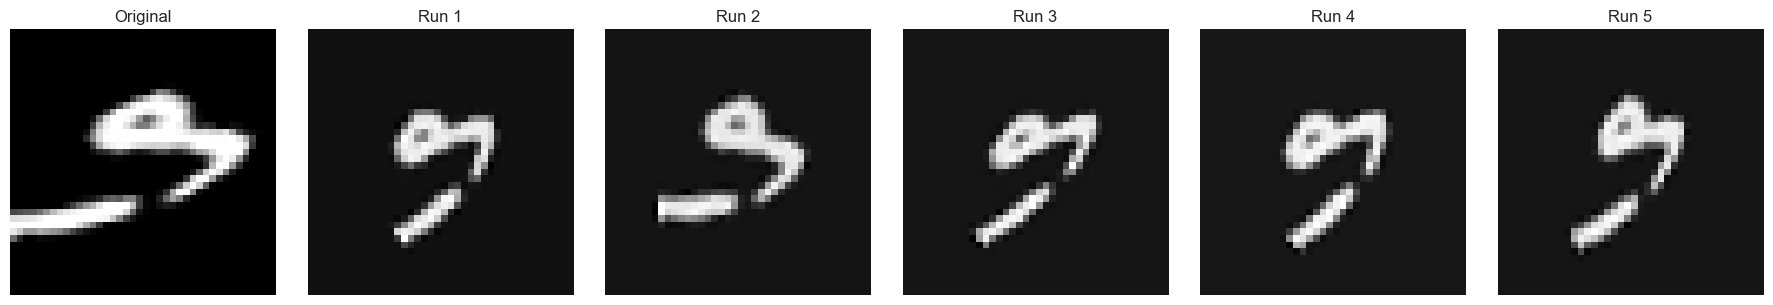

In [32]:
# Python
import torch

# Get a single batch (data, target) from the test loader
data, target = next(iter(test_loader_transformed))
data, target = data.cuda(), target.cuda()
data = data[8:9]  # Use only first 5 samples for testing
target = target[8:9]

# Number of repeated optimizations
num_repeats = 5
results = []
results_images = []

for i in range(num_repeats):
    res = optimizer.optimize(best_problem, data, y=target)
    zw = res[0]
    results.append(zw.detach().cpu())
    results_images.append(best_problem.transform(data, zw).detach().cpu())

# Compare the results
for idx, params in enumerate(results):
    print(f"Run {idx+1}: {params}")

if is_image_data:
    fig, axes = plt.subplots(1, num_repeats + 1, figsize=(3 * (num_repeats + 1), 3))
    # Show original image
    axes[0].imshow(data[0].cpu().permute(1, 2, 0).squeeze(), cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")
    # Apply each transformation and show result
    for i, params in enumerate(results_images):
        x_transformed = results_images[i]
        axes[i + 1].imshow(x_transformed[0].cpu().permute(1, 2, 0).squeeze(), cmap="gray")
        axes[i + 1].set_title(f"Run {i+1}")
        axes[i + 1].axis("off")
    plt.tight_layout()
    plt.show()


In [33]:
from search.shgo import SHGO

optimizer_120 = SHGO(initial_samples=120-27, local_runs=3, local_max_steps=4,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer_120 = SHGO(initial_samples=120,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

from utils.augments import small_affine_augment_2d, ComposeAugmentations, random_blur_or_sharpen
from utils.sampling_strategy import TransformLatentSamplingStrategy
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
from utils.transformation_problem import TransformationProblem

architecture_half = architecture+"_half"

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


energy_model2_half = get_network(dataset_info,architecture_half, num_classes=1).to(device)
from experiment_thesis.main import train_or_load_energy_model
negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    = transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)
energy_conf_half = train_or_load_energy_model(
    energy_model2_half, model_dir_path, f"{modelname}_energy2_half", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_half.to(device).eval()
problem_energy_half = TransformationProblem(energy_conf_half, transform_seq,                                              consolidate_method="consolidate_simple",max_batch_size=dataset_info.batch_size_search)


def savepath_later_layer(label: str) -> str:
    model_dir_path = os.path.join(current_path, "experiment_files", "models")
    embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
    # Add results dir and helper for save paths
    results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_supervised_methods")
    os.makedirs(results_dir_path, exist_ok=True)

    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

res_120 = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer_120, problem=problem_energy_half,
    test_loader=test_loader, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath_later_layer("learned_energy_confidence_half_transformed_120"), show_progress=True,
    repeats=5)

res_120_real_data = load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer_120, problem=problem_energy_half,
    test_loader=test_loader, max_batch_override=dataset_info.batch_size_search, show_progress=True, save_path=
    savepath_later_layer("learned_energy_confidence_half_transformed_120_untransformed"),
    repeats=5)



del energy_model2_half
del energy_conf_half

print(res_120["accuracy_mean"])

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_half_energy_conf_best.safetensors
Model has non-negative constraint: False


0.9775199890136719


In [34]:
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from typing import Optional, Tuple



In [35]:
def visualize_single_detector_transformations(
    model,
    optimizer,
    problem,
    test_loader,
    dataset_info,
    n_rows: int = 2,
    n_cols: int = 4,
    device: str = "cuda",
    save_prefix: Optional[str] = None
):
    """
    Visualize optimized transformations from a single detector/problem.
    Green border = correct classification, Red border = incorrect classification.
    Supports images, point clouds, and stroke sequences.

    Args:
        save_prefix: If provided, saves two PDFs: {prefix}_original.pdf and {prefix}_optimized.pdf
    """
    model.eval()
    n_samples = n_rows * n_cols

    # Get a batch of data
    data, target = next(iter(test_loader))
    data, target = data.to(device), target.to(device)
    data = data[:n_samples]
    target = target[:n_samples]

    # Determine data type
    data_shape = data.shape
    is_image = len(data_shape) == 4 and data_shape[1] in [1, 3]
    is_pointcloud = len(data_shape) == 3 and data_shape[-1] == 3
    is_stroke = len(data_shape) == 3 and data_shape[-1] == 4

    # Optimize
    res = optimizer.optimize(problem, data, y=target)
    params = res[0]
    x_optimized = problem.transform(data, params)

    # Get predictions
    with torch.no_grad():
        pred_orig = model(data).argmax(dim=-1)
        pred_opt = model(x_optimized).argmax(dim=-1)

    if is_image:
        _visualize_images_with_borders(
            data, x_optimized, target, pred_orig, pred_opt,
            n_rows, n_cols, save_prefix
        )
    elif is_pointcloud:
        _visualize_pointclouds_with_borders(
            data, x_optimized, target, pred_orig, pred_opt,
            n_rows, n_cols, save_prefix
        )
    elif is_stroke:
        _visualize_strokes_with_borders(
            data, x_optimized, target, pred_orig, pred_opt,
            n_rows, n_cols, save_prefix
        )
    else:
        print(f"Unsupported data shape: {data_shape}")
        return

    # Print statistics
    acc_orig = (pred_orig == target).float().mean().item()
    acc_opt = (pred_opt == target).float().mean().item()

    print(f"Accuracy - Original: {acc_orig:.3f}, Optimized: {acc_opt:.3f}")

    return {"accuracy_original": acc_orig, "accuracy_optimized": acc_opt}


def _visualize_images_with_borders(
    data, x_optimized, target, pred_orig, pred_opt,
    n_rows, n_cols, save_prefix
):
    """Helper to visualize images with colored borders."""
    # Clip to [0, 1]
    data = torch.clamp(data, 0, 1)
    x_optimized = torch.clamp(x_optimized, 0, 1)

    def add_border(img_tensor, is_correct):
        """Add colored border to image tensor (C, H, W)"""
        color = torch.tensor([0, 1, 0] if is_correct else [1, 0, 0], device=img_tensor.device)
        bordered = img_tensor.clone()

        # Handle grayscale
        if bordered.shape[0] == 1:
            bordered = bordered.repeat(3, 1, 1)

        # Add border
        border_width = 1
        for c in range(3):
            bordered[c, :border_width, :] = color[c]
            bordered[c, -border_width:, :] = color[c]
            bordered[c, :, :border_width] = color[c]
            bordered[c, :, -border_width:] = color[c]

        return bordered

    # Create bordered images
    n_samples = len(data)
    data_bordered = torch.stack([add_border(data[i], pred_orig[i] == target[i]) for i in range(n_samples)])
    opt_bordered = torch.stack([add_border(x_optimized[i], pred_opt[i] == target[i]) for i in range(n_samples)])

    # Create grids
    grid_orig = torchvision.utils.make_grid(data_bordered.cpu(), nrow=n_cols, padding=2)
    grid_opt = torchvision.utils.make_grid(opt_bordered.cpu(), nrow=n_cols, padding=2)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(12, 6 * n_rows / n_cols))
    axes[0].imshow(grid_orig.permute(1, 2, 0))
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(grid_opt.permute(1, 2, 0))
    axes[1].set_title('Optimized')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Save if requested
    if save_prefix:
        fig_orig, ax_orig = plt.subplots(1, 1, figsize=(6, 6 * n_rows / n_cols))
        ax_orig.imshow(grid_orig.permute(1, 2, 0))
        ax_orig.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_original.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_orig)

        fig_opt, ax_opt = plt.subplots(1, 1, figsize=(6, 6 * n_rows / n_cols))
        ax_opt.imshow(grid_opt.permute(1, 2, 0))
        ax_opt.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_optimized.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_opt)

        print(f"Saved: {save_prefix}_original.pdf and {save_prefix}_optimized.pdf")


def _visualize_pointclouds_with_borders(
    data, x_untransformed, target, pred_orig, pred_untrans,
    n_rows, n_cols, save_prefix
):
    """Helper to visualize point clouds with colored borders."""
    n_samples = len(data)

    # Display figure with both columns
    fig = plt.figure(figsize=(6 * n_cols, 3 * n_rows))
    for i in range(n_samples):
        row, col = i // n_cols, i % n_cols

        # Original/Transformed
        ax1 = fig.add_subplot(n_rows, 2 * n_cols, row * 2 * n_cols + col + 1, projection='3d')
        pts = data[i].cpu().numpy()
        color = 'green' if pred_orig[i] == target[i] else 'red'
        ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2, c=color)
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_zticks([])

        # Untransformed
        ax2 = fig.add_subplot(n_rows, 2 * n_cols, row * 2 * n_cols + n_cols + col + 1, projection='3d')
        pts_opt = x_untransformed[i].cpu().numpy()
        color_opt = 'green' if pred_untrans[i] == target[i] else 'red'
        ax2.scatter(pts_opt[:, 0], pts_opt[:, 1], pts_opt[:, 2], s=2, c=color_opt)
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.set_zticks([])

    plt.tight_layout()
    plt.show()

    # Save separate files
    if save_prefix:
        # Original/Transformed only
        fig_orig = plt.figure(figsize=(3 * n_cols, 3 * n_rows))
        for i in range(n_samples):
            row, col = i // n_cols, i % n_cols
            ax = fig_orig.add_subplot(n_rows, n_cols, i + 1, projection='3d')
            pts = data[i].cpu().numpy()
            color = 'green' if pred_orig[i] == target[i] else 'red'
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2, c=color)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_original.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_orig)

        # Untransformed only
        fig_untrans = plt.figure(figsize=(3 * n_cols, 3 * n_rows))
        for i in range(n_samples):
            row, col = i // n_cols, i % n_cols
            ax = fig_untrans.add_subplot(n_rows, n_cols, i + 1, projection='3d')
            pts_opt = x_untransformed[i].cpu().numpy()
            color_opt = 'green' if pred_untrans[i] == target[i] else 'red'
            ax.scatter(pts_opt[:, 0], pts_opt[:, 1], pts_opt[:, 2], s=2, c=color_opt)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_optimized.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_untrans)

        print(f"Saved: {save_prefix}_original.pdf and {save_prefix}_optimized.pdf")

def _visualize_strokes_with_borders(
    data, x_untransformed, target, pred_orig, pred_untrans,
    n_rows, n_cols, save_prefix
):
    """Helper to visualize stroke sequences with colored borders."""
    n_samples = len(data)

    # Display figure with both columns
    fig, axes = plt.subplots(n_rows, 2 * n_cols, figsize=(3 * 2 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_samples):
        row, col = i // n_cols, i % n_cols

        # Original/Transformed
        ax1 = axes[row, col]
        color = 'green' if pred_orig[i] == target[i] else 'red'
        _plot_stroke_on_ax(data[i].cpu(), ax1, color=color)

        # Untransformed
        ax2 = axes[row, n_cols + col]
        color_opt = 'green' if pred_untrans[i] == target[i] else 'red'
        _plot_stroke_on_ax(x_untransformed[i].cpu(), ax2, color=color_opt)

    # Hide extra subplots
    for i in range(n_samples, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis('off')
        axes[row, n_cols + col].axis('off')

    plt.tight_layout()
    plt.show()

    # Save separate files
    if save_prefix:
        # Original/Transformed only
        fig_orig, axes_orig = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
        if n_rows == 1:
            axes_orig = axes_orig.reshape(1, -1)
        for i in range(n_samples):
            row, col = i // n_cols, i % n_cols
            ax = axes_orig[row, col]
            color = 'green' if pred_orig[i] == target[i] else 'red'
            _plot_stroke_on_ax(data[i].cpu(), ax, color=color)
        for i in range(n_samples, n_rows * n_cols):
            row, col = i // n_cols, i % n_cols
            axes_orig[row, col].axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_original.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_orig)

        # Untransformed only
        fig_untrans, axes_untrans = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
        if n_rows == 1:
            axes_untrans = axes_untrans.reshape(1, -1)
        for i in range(n_samples):
            row, col = i // n_cols, i % n_cols
            ax = axes_untrans[row, col]
            color_opt = 'green' if pred_untrans[i] == target[i] else 'red'
            _plot_stroke_on_ax(x_untransformed[i].cpu(), ax, color=color_opt)
        for i in range(n_samples, n_rows * n_cols):
            row, col = i // n_cols, i % n_cols
            axes_untrans[row, col].axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(f"{save_prefix}_optimized.pdf", bbox_inches='tight', pad_inches=0)
        plt.close(fig_untrans)

        print(f"Saved: {save_prefix}_original.pdf and {save_prefix}_optimized.pdf")

def _plot_stroke_on_ax(seq, ax, linewidth=1.5, color="black"):
    """Plot single stroke sequence (N,4): dx,dy,pen,mask."""
    if isinstance(seq, torch.Tensor):
        seq = seq.detach().cpu().numpy()
    seq = np.asarray(seq)
    if seq.size == 0:
        return

    mask = seq[:, 3] if seq.shape[1] >= 4 else np.ones(seq.shape[0], dtype=bool)
    real_idx = mask == 1
    if not np.any(real_idx):
        return

    dx = seq[real_idx, 0]
    dy = seq[real_idx, 1]
    pen = seq[real_idx, 2] if seq.shape[1] >= 3 else np.zeros_like(dx)

    x = np.cumsum(dx)
    y = np.cumsum(dy)

    xs, ys = [], []
    for xi, yi, p in zip(x, y, pen):
        xs.append(xi)
        ys.append(-yi)
        if p == 1:
            ax.plot(xs, ys, linewidth=linewidth, color=color)
            xs, ys = [], []
    if xs:
        ax.plot(xs, ys, linewidth=linewidth, color=color)

    ax.axis("equal")
    ax.axis("off")

In [36]:
figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "a_visualization", dataset,
                           transform_name)
os.makedirs(figure_path, exist_ok=True)

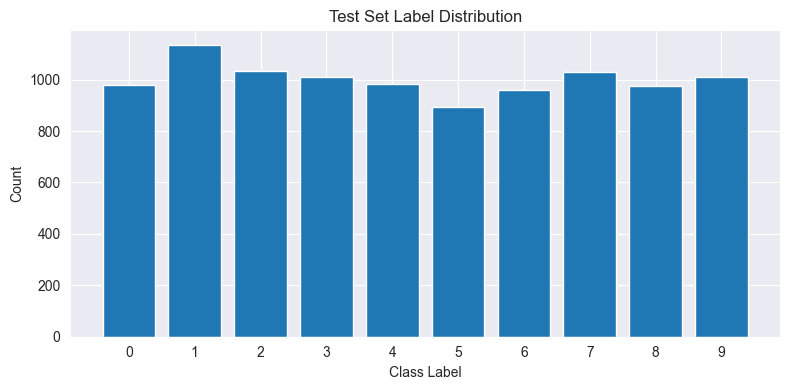

In [37]:
#print label distribution of test set
import matplotlib.pyplot as plt
import numpy as np

# Extract labels from test set
dataset = test_loader.dataset
labels = []
for i in range(len(dataset)):
    _, label = dataset[i]
    labels.append(label)
labels = np.array(labels)

# Plot label distribution
plt.figure(figsize=(8, 4))
plt.hist(labels, bins=np.arange(labels.min(), labels.max() + 2) - 0.5, rwidth=0.8)
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Test Set Label Distribution")
plt.xticks(np.unique(labels))
plt.tight_layout()
plt.show()


In [38]:
# Extract targets by iterating
dataset = test_loader.dataset
targets = []
for i in range(len(dataset)):
    _, target = dataset[i]
    targets.append(target)
targets = np.array(targets)

In [39]:
# Recreate test loaders with pre-shuffling to ensure class diversity
from torch.utils.data import DataLoader, Subset
import numpy as np

def create_class_balanced_subset(dataset, n_samples_per_class: int = 4):
    """
    Create a subset with n_samples_per_class from each class.
    Handles datasets that return 2 or 3 values.
    """
    # Get all targets
    if hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
    elif hasattr(dataset, 'labels'):
        targets = np.array(dataset.labels)
    else:
        # Extract targets by iterating
        targets = []
        for i in range(len(dataset)):
            item = dataset[i]
            # Handle both (data, target) and (data, params, target)
            target = item[-1]  # Target is always the last element
            targets.append(target)
        targets = np.array(targets)

    # Get unique classes
    unique_classes = np.unique(targets)
    #order them
    unique_classes = np.sort(unique_classes)
    print(unique_classes)

    # Sample indices for each class
    #set generator for reproducibility
    np.random.seed(42)

    selected_indices = []
    for cls in unique_classes:
        cls_indices = np.where(targets == cls)[0]
        # Shuffle and select
        np.random.shuffle(cls_indices)
        selected = cls_indices[:n_samples_per_class]
        selected_indices.extend(selected)

    # Shuffle the final selection
    np.random.shuffle(selected_indices)

    return Subset(dataset, selected_indices)

# Create balanced subsets
n_samples_per_class = 4  # Adjust based on n_rows * n_cols / n_classes
test_subset = create_class_balanced_subset(test_loader.dataset, n_samples_per_class)
test_subset_transformed = create_class_balanced_subset(test_loader_transformed.dataset, n_samples_per_class)

# Create loaders
test_loader= DataLoader(
    test_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader_transformed = DataLoader(
    test_subset_transformed,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Created balanced test loaders with {len(test_subset)} samples")
print(f"Expected classes: {n_classes}, samples per class: {n_samples_per_class}")


C:\Users\Lindner\AppData\Local\Temp\ipykernel_35576\1117858438.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
Created balanced test loaders with 40 samples
Expected classes: 10, samples per class: 4


Best Detector Results:


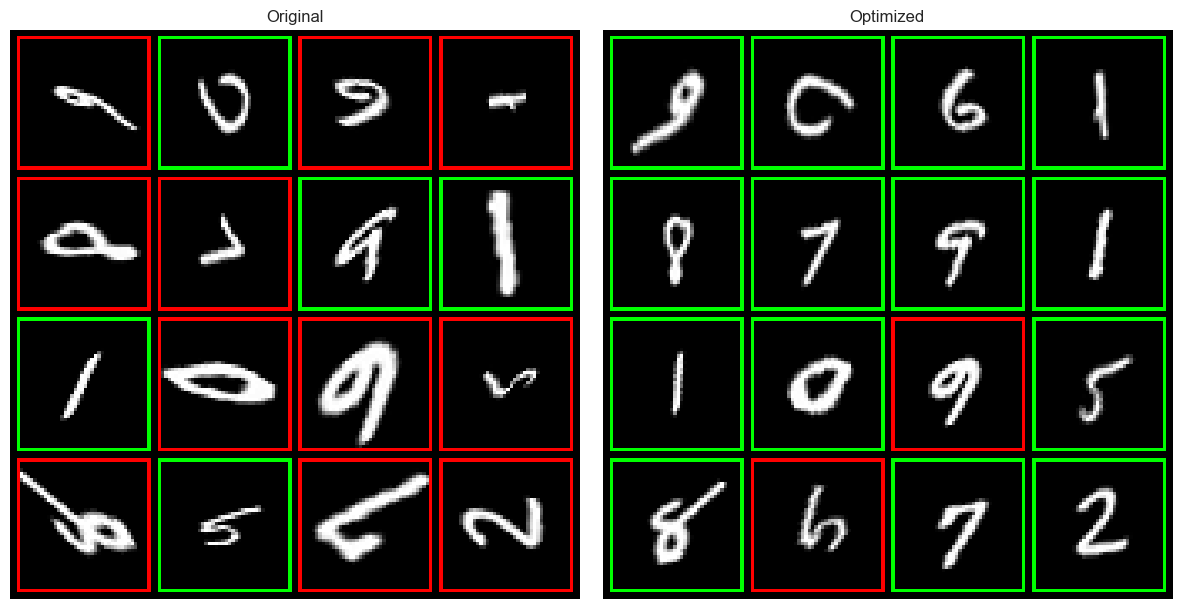

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\vis_best_detector_original.pdf and C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\vis_best_detector_optimized.pdf
Accuracy - Original: 0.312, Optimized: 0.875


In [40]:
# Visualize best detector
print("Best Detector Results:")
res_best = visualize_single_detector_transformations(
    model=model,
    optimizer=optimizer,
    problem=best_problem,
    test_loader=test_loader_transformed,
    dataset_info=dataset_info,
    n_rows=4,
    n_cols=4,
    device=device,
    save_prefix=os.path.join(figure_path, "vis_best_detector")
)




Energy Model Results:


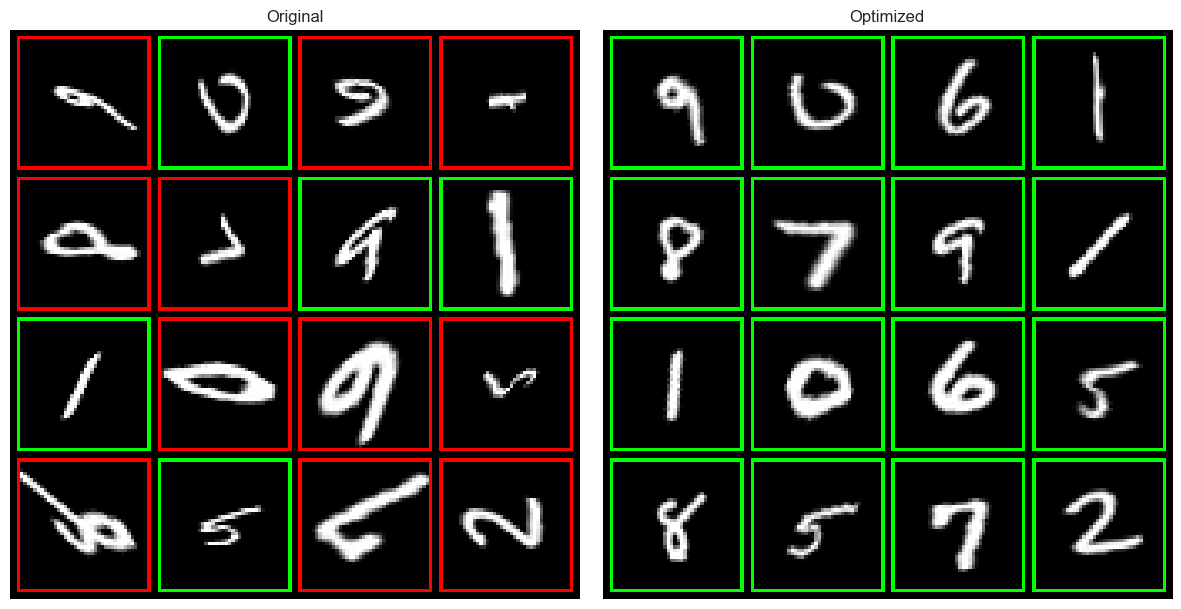

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\vis_energy_model_original.pdf and C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\vis_energy_model_optimized.pdf
Accuracy - Original: 0.312, Optimized: 1.000


In [41]:
# Visualize energy model
print("\nEnergy Model Results:")
res_energy = visualize_single_detector_transformations(
    model=model,
    optimizer=optimizer_120,
    problem=problem_energy_half,
    test_loader=test_loader_transformed,
    dataset_info=dataset_info,
    n_rows=4,
    n_cols=4,
    device=device,
    save_prefix=os.path.join(figure_path, "vis_energy_model")
)

In [42]:
def visualize_test_loader(
    test_loader,
    dataset_info,
    n_rows: int = 2,
    n_cols: int = 8,
    title: Optional[str] = None,
    save_path: Optional[str] = None
):
    """
    Visualize samples from test loader.
    Supports images, point clouds, and stroke sequences.

    Args:
        n_rows: Number of rows in the grid
        n_cols: Number of columns in the grid
        title: Optional title for the plot (shown in display only)
        save_path: If provided, saves the visualization as PDF (without title)
    """
    n_samples = n_rows * n_cols

    # Get data
    batch = next(iter(test_loader))
    data = batch[0][:n_samples]
    labels = batch[1][:n_samples] if len(batch) > 1 else None

    # Determine data type
    data_shape = data.shape

    if len(data_shape) == 4 and data_shape[1] in [1, 3]:  # Images (B, C, H, W)
        _visualize_images(data, labels, title, n_rows, n_cols, save_path)
    elif len(data_shape) == 3 and data_shape[-1] == 3:  # Point clouds (B, N, 3)
        _visualize_pointclouds(data, labels, title, n_rows, n_cols, save_path)
    elif len(data_shape) == 3 and data_shape[-1] == 4:  # Strokes (B, N, 4)
        _visualize_strokes(data, labels, title, n_rows, n_cols, save_path)
    else:
        print(f"Unsupported data shape: {data_shape}")


def _visualize_images(data, labels, title, n_rows, n_cols, save_path):
    """Helper to visualize image data."""
    grid = torchvision.utils.make_grid(data.cpu(), nrow=n_cols, normalize=True, padding=2)

    # Display with title
    if title:
        plt.figure(figsize=(12, 6 * n_rows / n_cols))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray' if data.shape[1] == 1 else None)
        plt.title(title)
        plt.axis('off')
        plt.tight_layout()


    # Save without title
    if save_path:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6 * n_rows / n_cols))
        ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray' if data.shape[1] == 1 else None)
        ax.axis('off')
        plt.tight_layout(pad=0)
        plt.savefig(save_path)
        print(f"Saved: {save_path}")


    plt.show()

def _visualize_pointclouds(data, labels, title, n_rows, n_cols, save_path):
    """Helper to visualize point cloud data."""
    n_samples = min(len(data), n_rows * n_cols)

    fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for i in range(n_samples):
        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')
        pts = data[i].cpu().numpy()
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        if labels is not None:
            ax.set_title(f"Label: {labels[i].item()}")

    if title:
        fig.suptitle(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()


def _visualize_strokes(data, labels, title, n_rows, n_cols, save_path):
    """Helper to visualize stroke sequence data."""
    n_samples = min(len(data), n_rows * n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_samples):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]

        seq = data[i].cpu().numpy()
        mask = seq[:, 3] == 1
        if np.any(mask):
            dx, dy, pen = seq[mask, 0], seq[mask, 1], seq[mask, 2]
            x, y = np.cumsum(dx), np.cumsum(dy)

            xs, ys = [], []
            for xi, yi, p in zip(x, y, pen):
                xs.append(xi)
                ys.append(-yi)
                if p == 1:
                    ax.plot(xs, ys, 'k-', linewidth=1.5)
                    xs, ys = [], []
            if xs:
                ax.plot(xs, ys, 'k-', linewidth=1.5)

        ax.axis('equal')
        ax.axis('off')
        if labels is not None:
            ax.set_title(f"Label: {labels[i].item()}", fontsize=10)

    # Hide extra subplots
    for i in range(n_samples, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]
        ax.axis('off')

    if title:
        fig.suptitle(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\test_loader_original.pdf


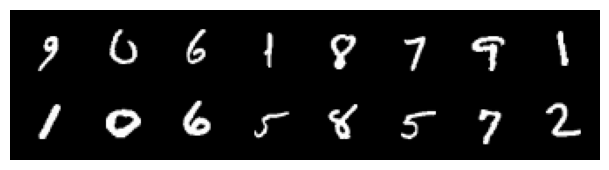

In [43]:

# Save without title
visualize_test_loader(
    test_loader,
    dataset_info,
    n_rows=2,
    n_cols=8,
    save_path=os.path.join(figure_path, "test_loader_original.pdf")
)
plt.show()



Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\test_loader_transformed.pdf


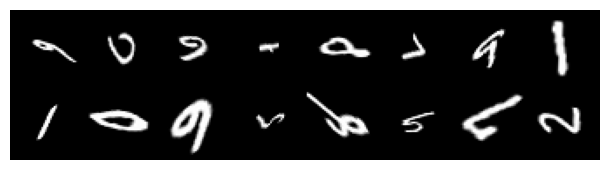

In [44]:
visualize_test_loader(
    test_loader_transformed,
    dataset_info,
    n_rows=2,
    n_cols=8,
    save_path=os.path.join(figure_path, "test_loader_transformed.pdf")
)
plt.show()


In [45]:
import os
import pickle

datasets = ["bigger_mnist", "bigger_emnist", "coil100", "tu_berlin", "modelnet10"]

latex_table = [
    r"\begin{tabular}{l|c}",
    r"Dataset & Accuracy \\ \hline"
]

for dataset in datasets:
    regression_cache_path = os.path.join(
        embedding_cache_path,
        f"regression_params_{dataset}_{default_architecutre_mapping[dataset]}_{get_dataset_info(dataset).transform_seq_name}_test_set.pkl"
    )
    if not os.path.exists(regression_cache_path):
        print(f"Cache not found for {dataset}, skipping.")
        continue
    with open(regression_cache_path, 'rb') as f:
        cache_data = pickle.load(f)
        test_acc_sim = cache_data.get('test_acc_sim', 0.0)
    latex_table.append(f"{dataset} & {test_acc_sim:.2f} \\\\")

latex_table.append(r"\end{tabular}")

print("\n".join(latex_table))

\begin{tabular}{l|c}
Dataset & Accuracy \\ \hline
bigger_mnist & 1.00 \\
bigger_emnist & 0.99 \\
coil100 & 1.00 \\
tu_berlin & 0.80 \\
modelnet10 & 1.00 \\
\end{tabular}


In [46]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

def visualize_regression_transformations(
    model,
    regression_dataloader,
    transform_seq_spatial,
    dataset_info,
    n_rows: int = 2,
    n_cols: int = 4,
    device: str = "cuda",
    save_prefix: Optional[str] = None
):
    """
    Visualize regression dataset transformations using stored parameters.
    Green border = correct classification, Red border = incorrect classification.

    Args:
        model: Classification model
        regression_dataloader: DataLoader with (data, params, target) tuples
        transform_seq_spatial: Transformation sequence to apply
        dataset_info: Dataset information
        n_rows: Number of rows in visualization grid
        n_cols: Number of columns in visualization grid
        device: Device to run on
        save_prefix: If provided, saves two PDFs: {prefix}_original.pdf and {prefix}_optimized.pdf
    """
    model.eval()
    n_samples = n_rows * n_cols

    # Get a batch from regression dataset
    data_batch = next(iter(regression_dataloader))
    data, params, target = data_batch
    data = data[:n_samples].to(device)
    params = params[:n_samples].to(device)
    target = target[:n_samples].to(device)

    # Apply stored transformation parameters to untransform
    T = transform_seq_spatial(params)
    x_untransformed = transform_seq_spatial.application_method(data, T)

    # Get predictions
    with torch.no_grad():
        pred_orig = model(data).argmax(dim=-1)
        pred_untrans = model(x_untransformed).argmax(dim=-1)

    # Determine data type
    data_shape = data.shape
    is_image = len(data_shape) == 4 and data_shape[1] in [1, 3]
    is_pointcloud = len(data_shape) == 3 and data_shape[-1] == 3
    is_stroke = len(data_shape) == 3 and data_shape[-1] == 4

    if is_image:
        _visualize_images_with_borders(
            data, x_untransformed, target, pred_orig, pred_untrans,
            n_rows, n_cols, save_prefix,
        )
    elif is_pointcloud:
        _visualize_pointclouds_with_borders(
            data, x_untransformed, target, pred_orig, pred_untrans,
            n_rows, n_cols, save_prefix,
        )
    elif is_stroke:
        _visualize_strokes_with_borders(
            data, x_untransformed, target, pred_orig, pred_untrans,
            n_rows, n_cols, save_prefix,
        )
    else:
        print(f"Unsupported data shape: {data_shape}")
        return

    # Print statistics
    acc_orig = (pred_orig == target).float().mean().item()
    acc_untrans = (pred_untrans == target).float().mean().item()

    print(f"Accuracy - Transformed: {acc_orig:.3f}, Untransformed (Canonical): {acc_untrans:.3f}")

    return {"accuracy_transformed": acc_orig, "accuracy_untransformed": acc_untrans}







[0 1 2 3 4 5 6 7 8 9]
Created balanced regression loader with 40 samples

Regression Dataset Canonical Transformation (Balanced):


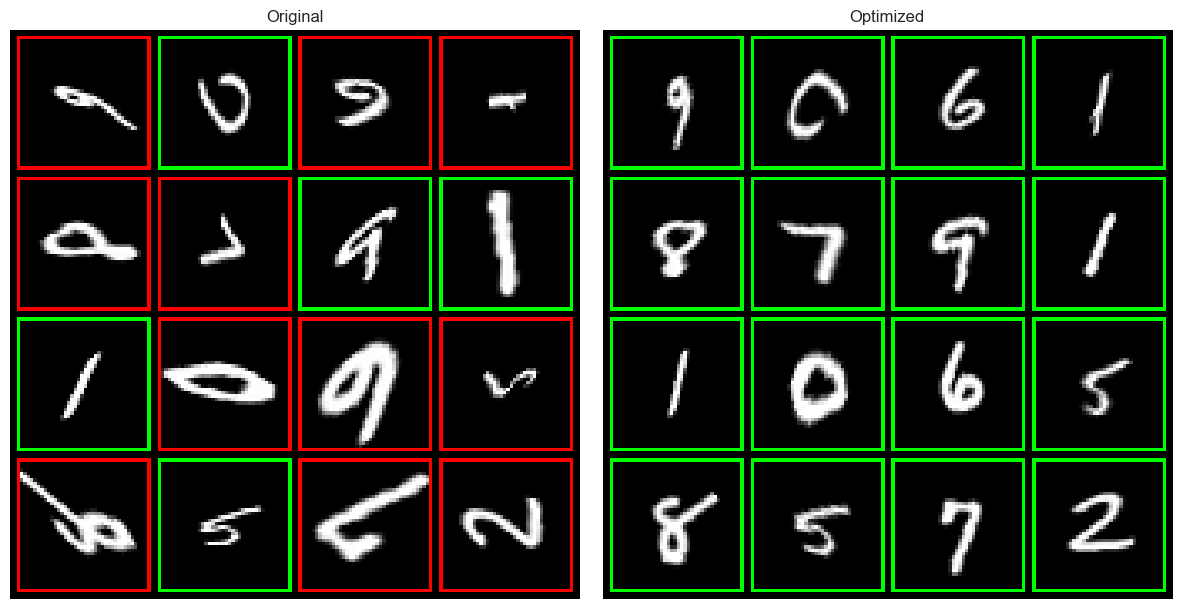

Saved: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\vis_regression_canonical_original.pdf and C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\export\fig\a_visualization\bigger_mnist\biggermnist_default\vis_regression_canonical_optimized.pdf
Accuracy - Transformed: 0.312, Untransformed (Canonical): 1.000


In [47]:
# Create regression loader with same balanced subset
regression_subset = create_class_balanced_subset(regression_dataset, n_samples_per_class)



regression_dataloader_balanced = DataLoader(
    regression_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Created balanced regression loader with {len(regression_subset)} samples")

# Visualize regression transformations with balanced subset
print("\nRegression Dataset Canonical Transformation (Balanced):")
res_regression = visualize_regression_transformations(
    model=model,
    regression_dataloader=regression_dataloader_balanced,
    transform_seq_spatial=transform_seq_spatial,
    dataset_info=dataset_info,
    n_rows=4,
    n_cols=4,
    device=device,
    save_prefix=os.path.join(figure_path, "vis_regression_canonical")
)